<a href="https://colab.research.google.com/github/Jaeik-Jeong/TCOParadox/blob/main/sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import time
import math
import matplotlib.pyplot as plt
import urllib.request

In [2]:
# ---------------------------------------------------------
# 1. 데이터 로드 및 전처리 (Sliding Window)
# ---------------------------------------------------------
FILE_PATH = 'https://raw.githubusercontent.com/Jaeik-Jeong/TCOParadox/refs/heads/main/1510080003.csv'

class PowerDataset(Dataset):
    def __init__(self, data, window_size=24):
        self.data = torch.FloatTensor(data.values)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        # 24시간 데이터를 보고 1시간 뒤(25번째)를 예측
        x = self.data[idx : idx + self.window_size]
        y = self.data[idx + self.window_size]
        return x, y

def prepare_data(file_path):
    df = pd.read_csv(file_path)
    # mrdDt를 datetime으로 변환 (YYYY-MM-DD HH)
    df['mrdDt'] = pd.to_datetime(df['mrdDt'], format='%Y-%m-%d %H')
    df = df.sort_values('mrdDt')

    # 1시간 단위 1년 데이터 (8760개 예상)
    values = df['pwrQrt']

    # 데이터 분할 (10:1:1)
    train_size = int(len(values) * (10/12))
    val_size = int(len(values) * (1/12))

    train_raw = values[:train_size]
    val_raw = values[train_size : train_size+val_size]
    test_raw = values[train_size+val_size:]

    # Train 데이터의 Max값 찾기
    P_MAX = train_raw.max()

    # 모든 데이터를 이 P_MAX로 나누기 (Scaling)
    train_data = train_raw / P_MAX
    val_data = val_raw / P_MAX
    test_data = test_raw / P_MAX

    return train_data, val_data, test_data, P_MAX

In [3]:
# ---------------------------------------------------------
# 2. 모델 정의 (MLP vs Transformer)
# ---------------------------------------------------------

# (1) MLP: 가볍고 빠른 모델
class MLPModel(nn.Module):
    def __init__(self, input_dim=24):
        super(MLPModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# (2) Transformer: 정확하지만 무거운 모델
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return x

# 수정된 Transformer 모델
class TransformerModel(nn.Module):
    def __init__(self, input_dim=24, d_model=64, nhead=4):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model) # 위치 정보 추가
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True),
            num_layers=2
        )
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.embedding(x)
        x = self.pos_encoder(x) # 임베딩에 위치 정보 더하기
        x = self.transformer(x)
        return self.fc(x[:, -1, :])

In [4]:
# ---------------------------------------------------------
# 3. 에너지 측정 및 추론 시뮬레이션
# ---------------------------------------------------------
def run_inference_with_energy(model, dataloader, p_avg):
    """
    model: 추론할 모델 (MLP 또는 Transformer)
    dataloader: 테스트 데이터로더 (batch_size=1 권장)
    p_avg: 모델 작동 시의 평균 소비 전력 (Watt). 기본값 25W.
    """
    model.eval()
    predictions = []
    actuals = []

    # 1. 순수 추론 시간 측정
    start_time = time.perf_counter()

    with torch.no_grad():
        for x, y in dataloader:
            output = model(x)
            predictions.append(output.cpu().numpy())
            actuals.append(y.cpu().numpy())

    end_time = time.perf_counter()

    # 2. 통계 및 에너지 계산
    total_time_sec = end_time - start_time
    total_samples = len(dataloader)

    # Z (Wh) = P(Watt) * (Total_Time / 3600) / Total_Samples
    avg_z_wh = (p_avg * (total_time_sec / 3600)) / total_samples
    avg_time_per_sample = total_time_sec / total_samples

    # 결과 리턴 (예측값, 실제값, 1회당 평균 에너지, 1회당 평균 시간)
    return np.array(predictions).flatten(), np.array(actuals).flatten(), avg_z_wh, avg_time_per_sample

In [5]:
# ---------------------------------------------------------
# 4. TCO Paradox 분석 및 시각화
# ---------------------------------------------------------
def analyze_tco(pred, actual, z, k_list, a1=1, a2=1, b=1):
    errors = np.abs(pred - actual)
    tco_results = {}

    for k in k_list:
        # TCO = a1*error + a2*z + b*(exp(kz)-1)
        # 여기서 z는 고정된 모델별 평균값 사용
        aging_cost = b * (np.exp(k * 3600 * z) - 1)
        tco_series = (a1 * errors) + (a2 * z) + aging_cost
        tco_results[k] = np.cumsum(tco_series)

    return tco_results

In [6]:
# ---------------------------------------------------------
# 5. Linear Regression (의사역행렬 방식)
# ---------------------------------------------------------
def train_linear_regression_pseudo(train_raw, seq_length=24):
    """
    의사역행렬 (X^T X)^-1 X^T y 를 이용하여
    Linear Regression의 가중치를 해석적으로 산출
    """
    # 데이터 준비
    X_list, y_list = [], []
    for i in range(len(train_raw) - seq_length):
        X_list.append(train_raw[i : i + seq_length])
        y_list.append(train_raw[i + seq_length])

    X = np.array(X_list) # (N, 24)
    y = np.array(y_list).reshape(-1, 1) # (N, 1)

    # Bias 항 추가 (입력 데이터 앞에 1 추가)
    X_b = np.c_[np.ones((X.shape[0], 1)), X]

    # 의사역행렬 계산: W = (X_b^T * X_b)^-1 * X_b^T * y
    # np.linalg.pinv를 사용하는 것이 수치적으로 더 안정적입니다.
    W = np.linalg.pinv(X_b) @ y
    return W

def predict_linear(W, x_input):
    """
    x_input: (batch, 24) shape torch tensor or numpy
    W: (25, 1) shape weights (including bias)
    """
    if torch.is_tensor(x_input):
        x_np = x_input.numpy()
    else:
        x_np = x_input

    x_b = np.c_[np.ones((x_np.shape[0], 1)), x_np]
    return x_b @ W

Model           | Avg MAE      | Avg Energy (Z) 
--------------------------------------------------
Linear Reg      | 0.179833     | 0.0000016543    Wh
MLP             | 0.176825     | 0.0000020628    Wh
Transformer     | 0.175035     | 0.0000221735    Wh


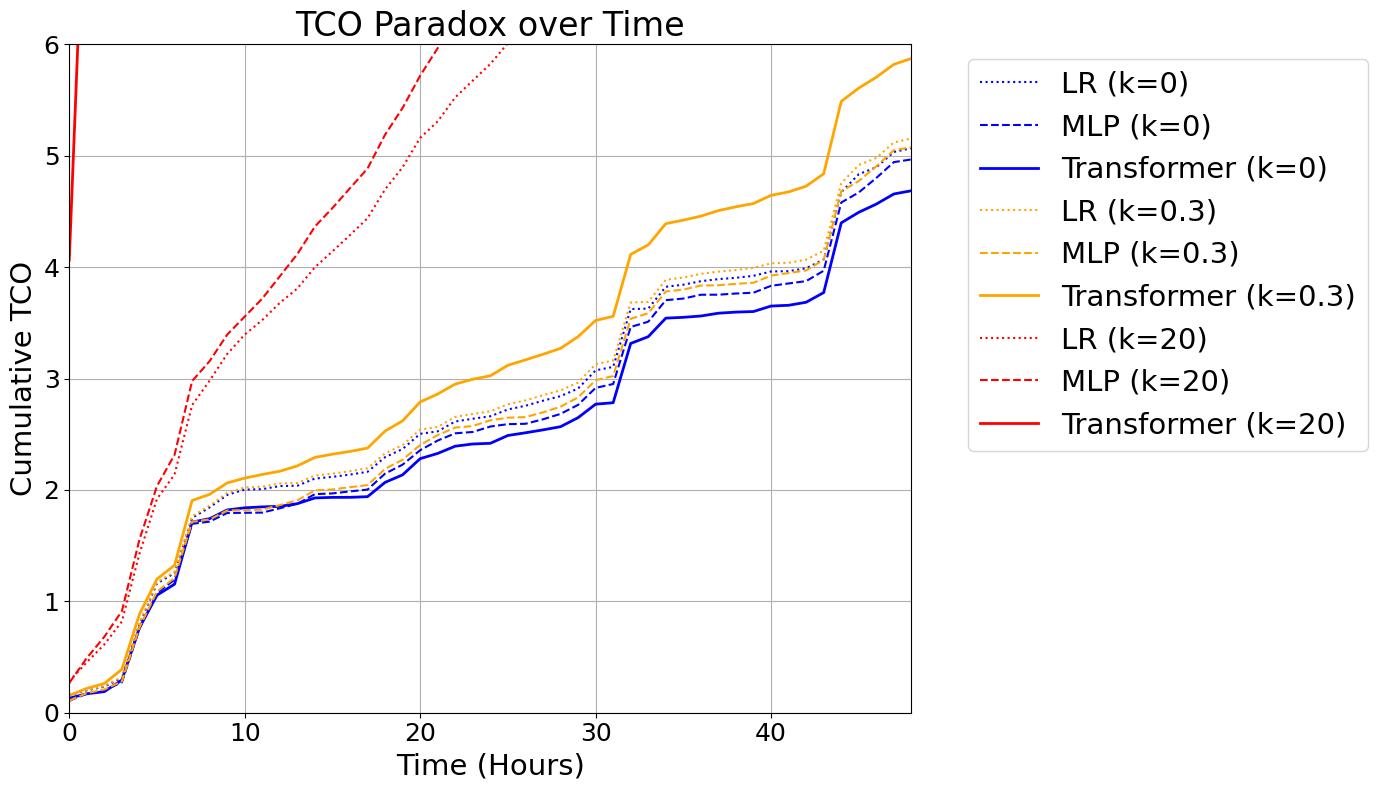

In [7]:
# ---------------------------------------------------------
# 6. 메인 실행 흐름
# ---------------------------------------------------------
p_avg = 25
train_raw, val_raw, test_raw, P_MAX = prepare_data(FILE_PATH)
test_loader = DataLoader(PowerDataset(test_raw), batch_size=1, shuffle=False)

# 모델 로드
urls = {
    "mlp": "https://github.com/Jaeik-Jeong/TCOParadox/raw/refs/heads/main/mlp_best.pt",
    "trans": "https://github.com/Jaeik-Jeong/TCOParadox/raw/refs/heads/main/transformer_best.pt"
}

mlp = MLPModel()
urllib.request.urlretrieve(urls["mlp"], 'mlp_best.pt')
mlp.load_state_dict(torch.load('mlp_best.pt', map_location='cpu'))
trans = TransformerModel()
urllib.request.urlretrieve(urls["trans"], 'transformer_best.pt')
trans.load_state_dict(torch.load('transformer_best.pt', map_location='cpu'))

# [1] Linear Regression (의사역행렬 방식)
W_lr = train_linear_regression_pseudo(train_raw)
start_lr = time.perf_counter()
pred_lr, actual_lr = [], []
for x, y in test_loader:
    p = predict_linear(W_lr, x)
    pred_lr.append(p[0, 0])
    actual_lr.append(y.item())
end_lr = time.perf_counter()

pred_lr, actual_lr = np.array(pred_lr), np.array(actual_lr)
mae_lr = np.mean(np.abs(pred_lr - actual_lr)) * P_MAX
z_lr = (p_avg * ((end_lr - start_lr) / len(test_loader))) / 3600

# [2] MLP 분석
pred_mlp, actual_mlp, z_mlp, _ = run_inference_with_energy(mlp, test_loader, p_avg)
mae_mlp = np.mean(np.abs(pred_mlp - actual_mlp)) * P_MAX

# [3] Transformer 분석
pred_trans, actual_trans, z_trans, _ = run_inference_with_energy(trans, test_loader, p_avg)
mae_trans = np.mean(np.abs(pred_trans - actual_trans)) * P_MAX

# ---------------------------------------------------------
# 최종 결과 출력 (논문 데이터로 활용)
# ---------------------------------------------------------
print("="*50)
print(f"{'Model':<15} | {'Avg MAE':<12} | {'Avg Energy (Z)':<15}")
print("-"*50)
print(f"{'Linear Reg':<15} | {mae_lr:<12.6f} | {z_lr:<15.10f} Wh")
print(f"{'MLP':<15} | {mae_mlp:<12.6f} | {z_mlp:<15.10f} Wh")
print(f"{'Transformer':<15} | {mae_trans:<12.6f} | {z_trans:<15.10f} Wh")
print("="*50)

# TCO 분석 시나리오 실행
k_values = [0, 0.3, 20] # 패러독스를 잘 보여주는 k값 설정
results_lr = analyze_tco(pred_lr, actual_lr, z_lr, k_values)
results_mlp = analyze_tco(pred_mlp, actual_mlp, z_mlp, k_values)
results_trans = analyze_tco(pred_trans, actual_trans, z_trans, k_values)

# 그래프 시각화
fig_tco_time = plt.figure(figsize=(14, 8))
colors = {k_values[0]: 'blue', k_values[1]: 'orange', k_values[2]: 'red'}

for k in k_values:
    plt.plot(results_lr[k], label=f'LR (k={k})', linestyle=':', color=colors[k])
    plt.plot(results_mlp[k], label=f'MLP (k={k})', linestyle='--', color=colors[k])
    plt.plot(results_trans[k], label=f'Transformer (k={k})', linewidth=2, color=colors[k])

plt.title("TCO Paradox over Time", fontsize=24)
plt.xlabel("Time (Hours)", fontsize=21)
plt.xlim(0,48)
plt.xticks(fontsize=18)
plt.ylabel("Cumulative TCO", fontsize=21)
plt.ylim(0,6)
plt.yticks(fontsize=18)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=21)
plt.grid(True)
plt.tight_layout()
plt.show()

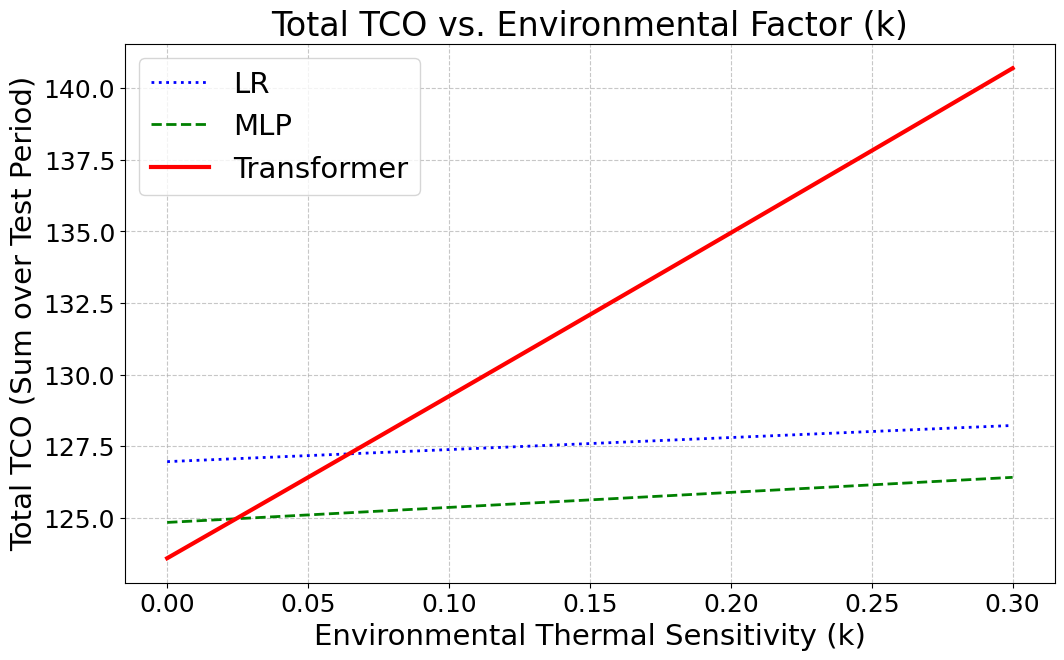

In [8]:
# ---------------------------------------------------------
# 7. k 변화에 따른 최종 TCO 분석 1
# ---------------------------------------------------------

# k 범위를 0부터 5까지 세밀하게 설정 (예: 100단계)
k_range = np.linspace(0, 0.3, 100)

def get_total_tco_at_k(pred, actual, z, k, a1=1, a2=1, b=1):
    """특정 k값에서의 전체 테스트 기간 총 TCO 합계를 반환"""
    errors = np.abs(pred - actual)
    # 1회 추론당 비용 계산
    # z는 Wh 단위이므로, 수식 내에서 초 단위(3600)로 보정하거나 k의 스케일에 맞춰 조정
    aging_cost = b * (np.exp(k * 3600 * z) - 1)
    tco_per_step = (a1 * errors) + (a2 * z) + aging_cost
    return np.sum(tco_per_step)

# 각 모델별로 k 변화에 따른 총 TCO 리스트 생성
tco_totals_lr = [get_total_tco_at_k(pred_lr * P_MAX, actual_lr * P_MAX, z_lr, k) for k in k_range]
tco_totals_mlp = [get_total_tco_at_k(pred_mlp * P_MAX, actual_mlp * P_MAX, z_mlp, k) for k in k_range]
tco_totals_trans = [get_total_tco_at_k(pred_trans * P_MAX, actual_trans * P_MAX, z_trans, k) for k in k_range]

# 그래프 시각화
fig_tco_k1 = plt.figure(figsize=(12, 7))

plt.plot(k_range, tco_totals_lr, label='LR', linestyle=':', color='blue', linewidth=2)
plt.plot(k_range, tco_totals_mlp, label='MLP', linestyle='--', color='green', linewidth=2)
plt.plot(k_range, tco_totals_trans, label='Transformer', color='red', linewidth=3)

# 역전이 일어나는 지점(Crossover Point) 강조 (선택 사항)
# Transformer와 MLP가 만나는 지점 찾기 등 가능

plt.title("Total TCO vs. Environmental Factor (k)", fontsize=24)
plt.xlabel("Environmental Thermal Sensitivity (k)", fontsize=21)
plt.xticks(fontsize=18)
plt.ylabel("Total TCO (Sum over Test Period)", fontsize=21)
plt.yticks(fontsize=18)
plt.legend(fontsize=21)
plt.grid(True, linestyle='--', alpha=0.7)

# y축이 너무 급격히 변할 경우 로그 스케일 검토 가능
# plt.yscale('log')

plt.show()

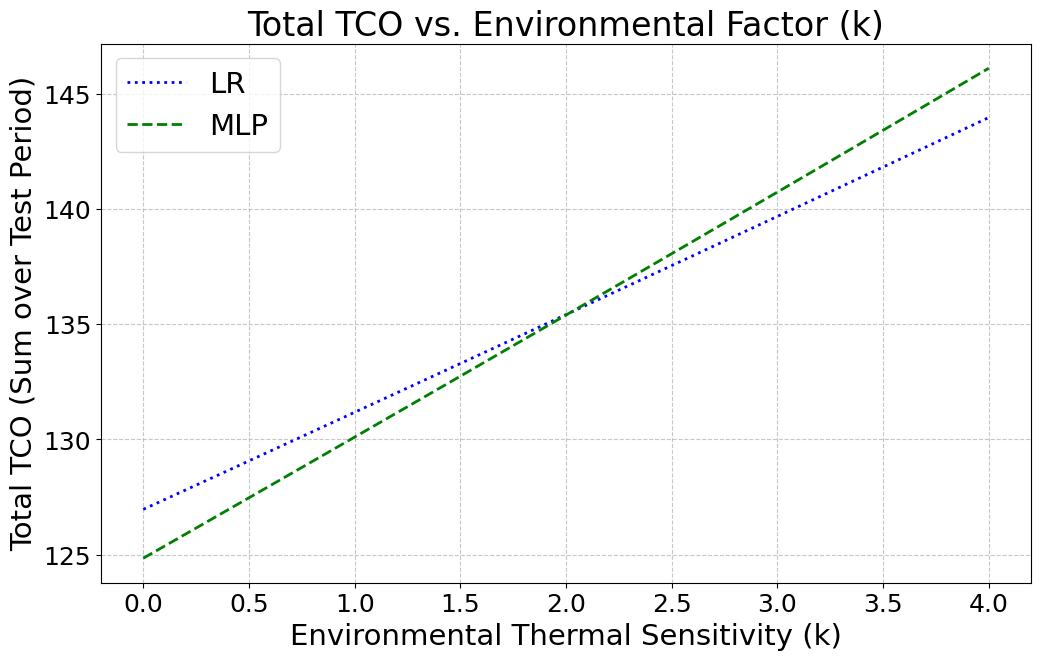

In [12]:
# ---------------------------------------------------------
# 8. k 변화에 따른 최종 TCO 분석 2
# ---------------------------------------------------------

# k 범위를 0부터 5까지 세밀하게 설정 (예: 100단계)
k_range = np.linspace(0, 4, 100)

def get_total_tco_at_k(pred, actual, z, k, a1=1, a2=1, b=1):
    """특정 k값에서의 전체 테스트 기간 총 TCO 합계를 반환"""
    errors = np.abs(pred - actual)
    # 1회 추론당 비용 계산
    # z는 Wh 단위이므로, 수식 내에서 초 단위(3600)로 보정하거나 k의 스케일에 맞춰 조정
    aging_cost = b * (np.exp(k * 3600 * z) - 1)
    tco_per_step = (a1 * errors) + (a2 * z) + aging_cost
    return np.sum(tco_per_step)

# 각 모델별로 k 변화에 따른 총 TCO 리스트 생성
tco_totals_lr = [get_total_tco_at_k(pred_lr * P_MAX, actual_lr * P_MAX, z_lr, k) for k in k_range]
tco_totals_mlp = [get_total_tco_at_k(pred_mlp * P_MAX, actual_mlp * P_MAX, z_mlp, k) for k in k_range]

# 그래프 시각화
fig_tco_k2 = plt.figure(figsize=(12, 7))

plt.plot(k_range, tco_totals_lr, label='LR', linestyle=':', color='blue', linewidth=2)
plt.plot(k_range, tco_totals_mlp, label='MLP', linestyle='--', color='green', linewidth=2)

plt.title("Total TCO vs. Environmental Factor (k)", fontsize=24)
plt.xlabel("Environmental Thermal Sensitivity (k)", fontsize=21)
plt.xticks(fontsize=18)
plt.ylabel("Total TCO (Sum over Test Period)", fontsize=21)
plt.yticks(fontsize=18)
plt.legend(fontsize=21)
plt.grid(True, linestyle='--', alpha=0.7)

# y축이 너무 급격히 변할 경우 로그 스케일 검토 가능
# plt.yscale('log')

plt.show()

In [10]:
#fig_tco_time.savefig('fig_tco_time.pdf', bbox_inches='tight', format='pdf', dpi=1000)
#fig_tco_k1.savefig('fig_tco_k1.pdf', bbox_inches='tight', format='pdf', dpi=1000)
#fig_tco_k2.savefig('fig_tco_k2.pdf', bbox_inches='tight', format='pdf', dpi=1000)
#fig_paradox.savefig('fig_paradox.pdf', bbox_inches='tight', format='pdf', dpi=1000)